In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ta.trend import MACD, SMAIndicator, EMAIndicator
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

# Ladda sparad data
raw = pd.read_csv("../data/raw_crypto.csv", header=[0,1], index_col=0, parse_dates=True)
print("Data laddad!")
print(raw.shape)

Data laddad!
(2991, 25)


In [9]:
def build_features(df):
    """Bygger tekniska indikatorer för en crypto"""
    data = df.copy()
    close = data["Close"]
    
    # ── Trend ────────────────────────────────────────
    data["MA_50"]  = SMAIndicator(close, window=50).sma_indicator()
    data["MA_200"] = SMAIndicator(close, window=200).sma_indicator()
    data["Golden_Cross"] = (data["MA_50"] > data["MA_200"]).astype(int)
    # 1 = Golden Cross (bullish), 0 = Death Cross (bearish)
    
    # ── Momentum ─────────────────────────────────────
    data["RSI"] = RSIIndicator(close, window=14).rsi()
    
    macd = MACD(close)
    data["MACD"]        = macd.macd()
    data["MACD_signal"] = macd.macd_signal()
    data["MACD_diff"]   = macd.macd_diff()
    
    # ── Volatilitet ───────────────────────────────────
    bb = BollingerBands(close, window=20)
    data["BB_high"]  = bb.bollinger_hband()
    data["BB_low"]   = bb.bollinger_lband()
    data["BB_width"] = bb.bollinger_wband()
    
    # ── Pris-features ────────────────────────────────
    data["Daily_return"]   = close.pct_change()
    data["Log_return"]     = np.log(close / close.shift(1))
    data["High_Low_range"] = data["High"] - data["Low"]
    data["Price_change"]   = data["Close"] - data["Open"]
    
    # ── Target (vad vi vill prediktera) ──────────────
    data["Target"] = (close.shift(-1) > close).astype(int)
    # 1 = priset går UPP imorgon, 0 = priset går NED
    
    return data.dropna()

print("Funktion skapad!")

Funktion skapad!


In [ ]:
# Target — Upp eller ned imorgon (0/1)
all_data["BTC-USD"]["Target"].value_counts()

Target
1    1417
0    1375
Name: count, dtype: int64

In [15]:
cryptos = ["BTC-USD", "ETH-USD", "BNB-USD", "SOL-USD", "XRP-USD"]
all_data = {}

for ticker in cryptos:
    df = raw[ticker].copy()
    df = build_features(df)
    all_data[ticker] = df
    print(f"{ticker}: {df.shape} — Features: {df.shape[1]} kolumner")

BTC-USD: (2792, 20) — Features: 20 kolumner
ETH-USD: (2792, 20) — Features: 20 kolumner
BNB-USD: (2792, 20) — Features: 20 kolumner
SOL-USD: (1962, 20) — Features: 20 kolumner
XRP-USD: (2792, 20) — Features: 20 kolumner


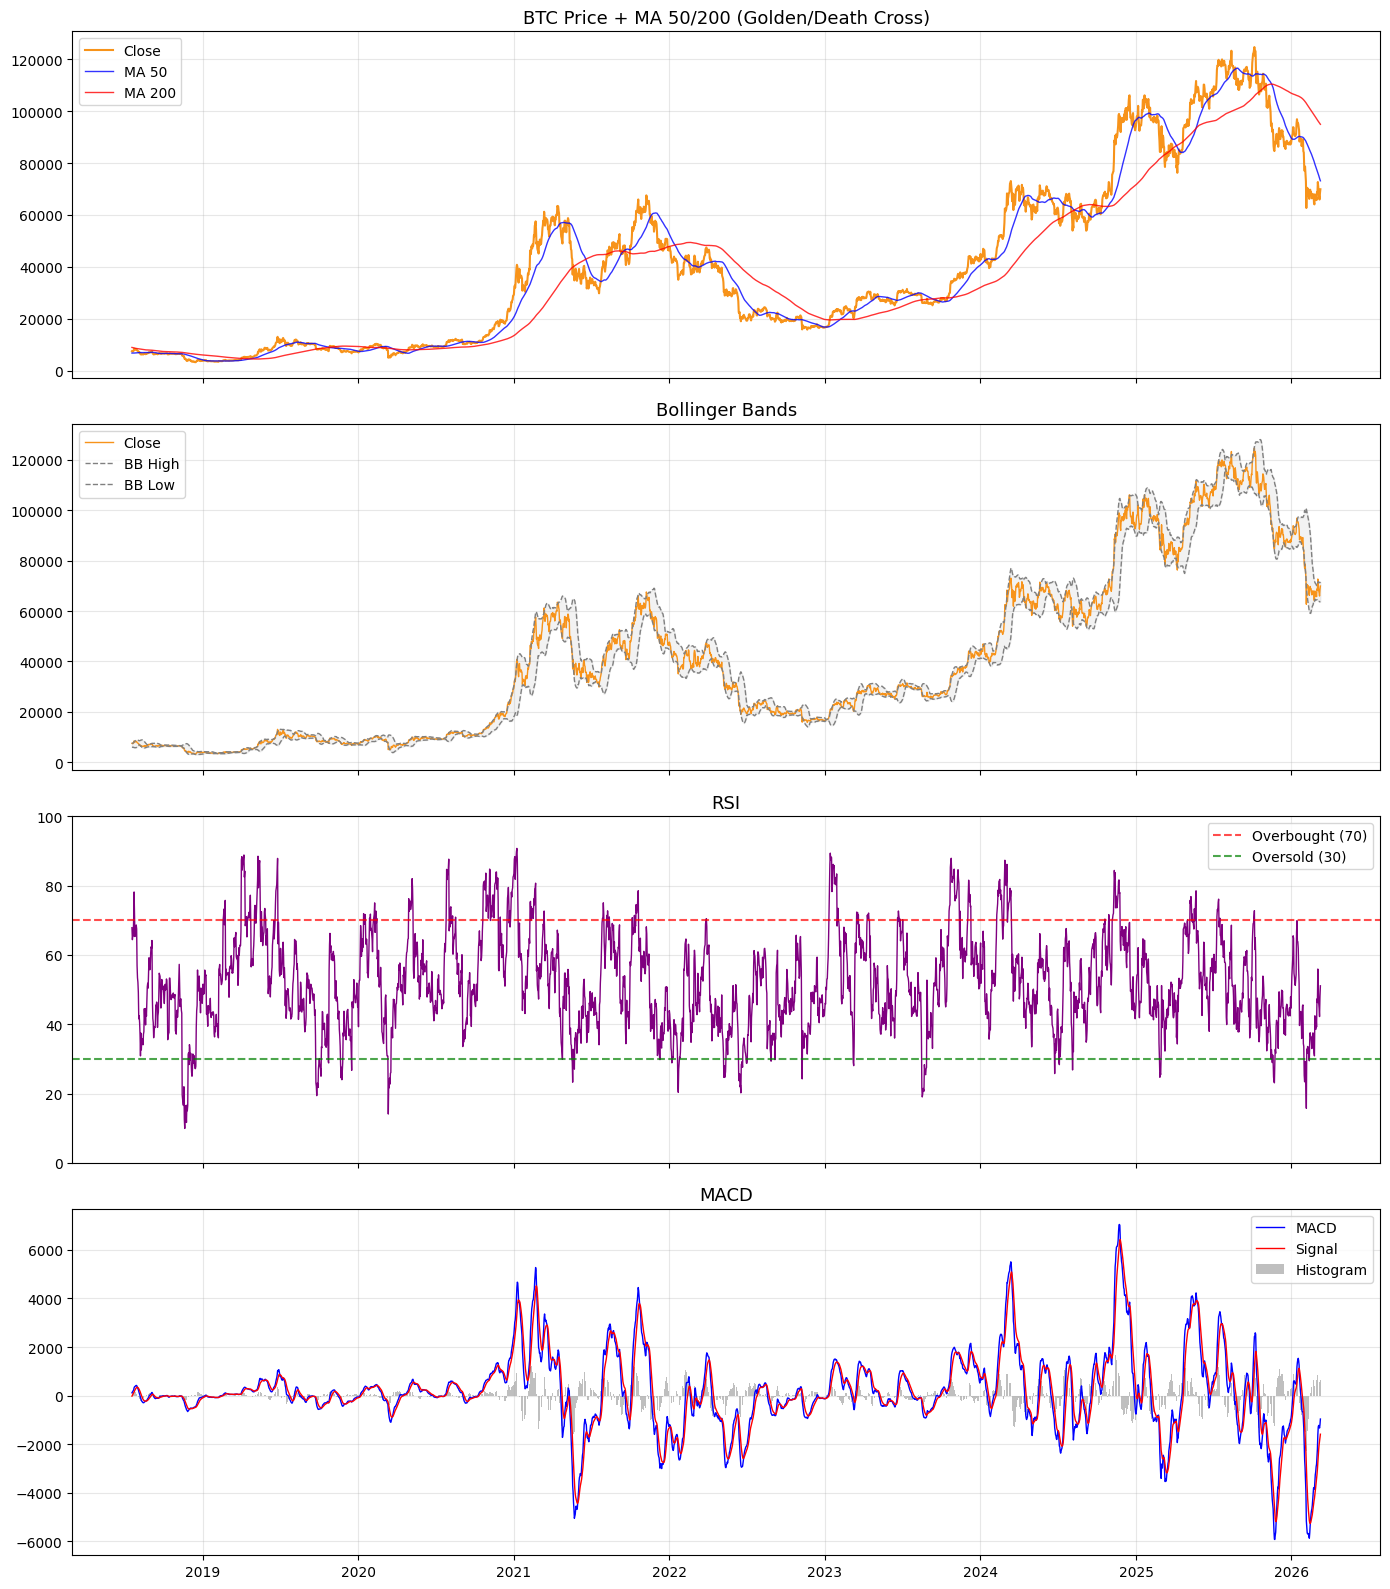

In [11]:
btc = all_data["BTC-USD"]

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Pris + Moving Averages
axes[0].plot(btc.index, btc["Close"],  color="#F7931A", linewidth=1.5, label="Close")
axes[0].plot(btc.index, btc["MA_50"],  color="blue",   linewidth=1,   label="MA 50",  alpha=0.8)
axes[0].plot(btc.index, btc["MA_200"], color="red",    linewidth=1,   label="MA 200", alpha=0.8)
axes[0].set_title("BTC Price + MA 50/200 (Golden/Death Cross)", fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bollinger Bands
axes[1].plot(btc.index, btc["Close"],   color="#F7931A", linewidth=1,   label="Close")
axes[1].plot(btc.index, btc["BB_high"], color="gray",    linewidth=1,   label="BB High", linestyle="--")
axes[1].plot(btc.index, btc["BB_low"],  color="gray",    linewidth=1,   label="BB Low",  linestyle="--")
axes[1].fill_between(btc.index, btc["BB_low"], btc["BB_high"], alpha=0.1, color="gray")
axes[1].set_title("Bollinger Bands", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# RSI
axes[2].plot(btc.index, btc["RSI"], color="purple", linewidth=1)
axes[2].axhline(y=70, color="red",   linestyle="--", alpha=0.7, label="Overbought (70)")
axes[2].axhline(y=30, color="green", linestyle="--", alpha=0.7, label="Oversold (30)")
axes[2].set_ylim(0, 100)
axes[2].set_title("RSI", fontsize=13)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# MACD
axes[3].plot(btc.index, btc["MACD"],        color="blue", linewidth=1, label="MACD")
axes[3].plot(btc.index, btc["MACD_signal"], color="red",  linewidth=1, label="Signal")
axes[3].bar(btc.index,  btc["MACD_diff"],   color="gray", alpha=0.5,  label="Histogram")
axes[3].set_title("MACD", fontsize=13)
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Spara alla cryptos med features
for ticker, df in all_data.items():
    filename = ticker.replace("-", "_").lower()
    df.to_csv(f"../data/{filename}_features.csv")
    print(f"Sparad: {filename}_features.csv")

print("\n✅ Fas 2 klar! Redo för modellträning!")

Sparad: btc_usd_features.csv
Sparad: eth_usd_features.csv
Sparad: bnb_usd_features.csv
Sparad: sol_usd_features.csv
Sparad: xrp_usd_features.csv

✅ Fas 2 klar! Redo för modellträning!
